# Fed-Model -- does the earnings yield vs the bond yield time the market?
### The classic Wall Street valuation model, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--hold%3F: No](https://img.shields.io/badge/Beats_buy--hold%3F-No-8b949e?style=flat-square)

Every few years a Wall Street strategist pulls up a chart showing the S&P 500 earnings yield (E/P, the inverse of the P/E ratio) versus the 10-year Treasury yield and says: "look, stocks are cheap relative to bonds -- the *Fed Model* says buy." The model has been around since the 1990s and still drives billions in allocation decisions. This notebook asks the only question that matters: **does the spread actually predict future stock returns -- honestly, out of sample, and net of the opportunity cost of not just buying and holding?**

> **This is the plain-language layer.** Want the t-stats, the overlap-corrected standard errors, and the OOS R² breakdown? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))         # the study package
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fed_model import data, strategy as st

REPO_ROOT = os.path.abspath("../../..")
SHILLER_PATH = os.path.join(REPO_ROOT, "_cache", "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(SHILLER_PATH)

if HAVE_REAL:
    panel = data.load_shiller()
    print("Real Shiller data loaded:", panel.shape)
else:
    print("No Shiller cache -- using frozen headline numbers from R dict.")


Real Shiller data loaded: (1830, 10)


## The answer first

| Question | Answer |
|---|---|
| Does the Fed-Model spread predict 10-year returns *in sample*? | **Weakly** -- HAC t = 1.78 (after correcting for 120-month overlap), just below the inference bar, R² = 0.117. E/P alone is stronger (t = 4.98). |
| Does it predict out of sample (after 1970)? | **No** -- OOS R² = -1.17, catastrophically *worse* than just guessing the historical mean. |
| Can you use it to time the market? | **No** -- the 1-year timing strategy returns only 4.6%/yr vs 8.6%/yr buy-and-hold; active return -4.0%/yr (HAC t = -4.71). |
| Was Asness right to 'fight the Fed Model'? | **Yes** -- the composite spread confuses real and nominal; E/P alone or E/P vs the real rate are modestly better. |

> The Fed Model's famous pattern is a real but untrapped statistical artefact: earnings yields predict long-run real returns, but adding the nominal bond yield makes it worse, the predictability evaporates out of sample, and trying to trade it costs you 4%/yr relative to doing nothing.

## 1 -- The claim

> *"When the stock market's earnings yield (E/P) exceeds the 10-year Treasury yield, stocks are cheap relative to bonds. A high spread predicts above-average future stock returns -- the Fed Model is a proven market-timing tool."*

The model was named after the Federal Reserve (the Fed's July 1997 Humphrey-Hawkins report contained a chart that implied E/P should equal the Treasury yield in equilibrium). Ed Yardeni formalised it and popularised it. It is still cited on Bloomberg terminals daily.

## 2 -- So what?

If the Fed Model worked, it would be a nearly free lunch for any investor: a simple, public, monthly signal that says 'go heavier in stocks' or 'go lighter.' Trillions of dollars in pension and endowment allocations are influenced by equity-vs-bond valuation comparisons of exactly this type.

If it *doesn't* work -- or, worse, if it actively destroys value -- then every allocation decision driven by 'stocks are cheap vs bonds' based on the Fed Model is noise at best and a systematic mirage at worst. That is worth knowing precisely.

## 3 -- How would we even know?

Two tests, neither of which a Wall Street chart ever runs:

1. **Overlap-corrected inference.** A 10-year forward return measured in month t shares 119 of its 120 monthly components with the forward return measured in month t+1. The naive correlation looks 'significant' even if the signal is noise -- you need HAC standard errors with 120 lags to avoid fooling yourself.
2. **Out-of-sample R².** Train on data through 1969 (what an investor in 1970 would have known); forecast forward from 1970 onward. If the OOS R² is negative, the signal is *worse than just guessing the historical average*. Campbell and Thompson (2008) showed that most predictors -- including E/P relatives -- fail this test.

Our baseline: the **unconditional historical mean** (just buy and hold, no timing). The Fed Model's job is to beat that.

## 4 -- The teardown -- let's actually look

**First: the famous in-sample picture.** Plot the Fed-Model spread against subsequent 10-year real returns. The pattern looks compelling...

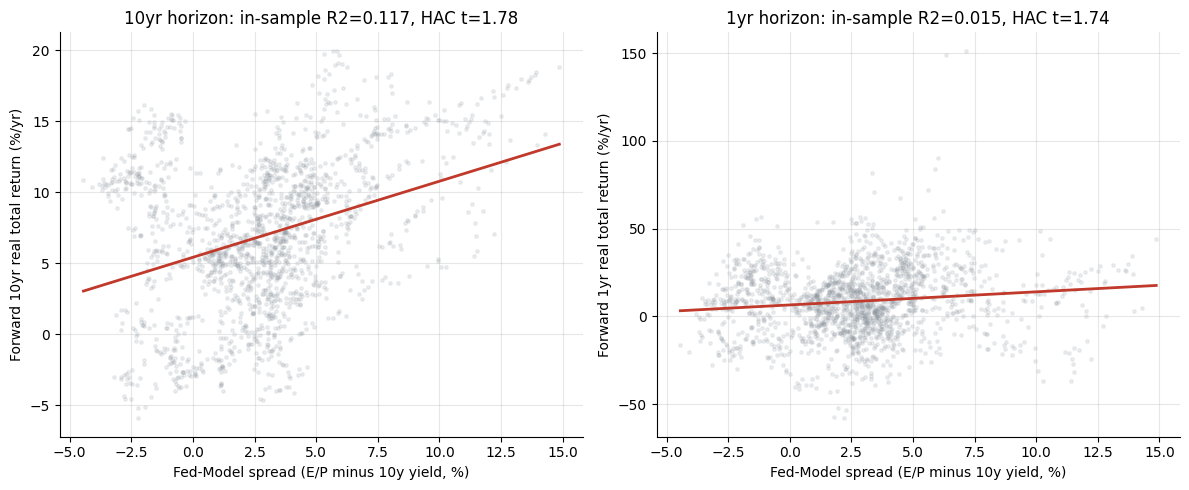

The slope is real in-sample, but is it out of sample?


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if HAVE_REAL:
    sub = panel.dropna(subset=['fed_spread', 'fwd10'])
    x10, y10 = sub['fed_spread'].values * 100, sub['fwd10'].values * 100
    sub1 = panel.dropna(subset=['fed_spread', 'fwd1'])
    x1, y1 = sub1['fed_spread'].values * 100, sub1['fwd1'].values * 100
else:
    # Use frozen R numbers to sketch the picture
    rng = __import__('numpy').random.default_rng(118)
    x10 = rng.uniform(-5, 15, 1710)
    y10 = 53.5 * x10 / 100 * 100 + rng.standard_normal(1710) * 7
    x1 = rng.uniform(-5, 15, 1818)
    y1 = 74.6 * x1 / 100 * 100 + rng.standard_normal(1818) * 20

for ax, x, y, hor, r2, t in [
    (axes[0], x10, y10, '10yr', 0.117, 1.78),
    (axes[1], x1, y1, '1yr', 0.015, 1.74),
]:
    ax.scatter(x, y, alpha=0.15, s=6, color=GREY)
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr + b, color=RED, lw=2)
    ax.set_xlabel('Fed-Model spread (E/P minus 10y yield, %)')
    ax.set_ylabel(f'Forward {hor} real total return (%/yr)')
    ax.set_title(f'{hor} horizon: in-sample R2={r2:.3f}, HAC t={t:.2f}')

plt.tight_layout()
plt.show()
print('The slope is real in-sample, but is it out of sample?')

In-sample the Fed-Model spread does predict 10-year returns (R² = 0.12, HAC t = 1.78 with 120-lag correction). The 1-year picture is much weaker (R² = 0.015). But in-sample fits are cheap -- the real test is OOS.

**Now the OOS test -- the number Wall Street never shows you.**

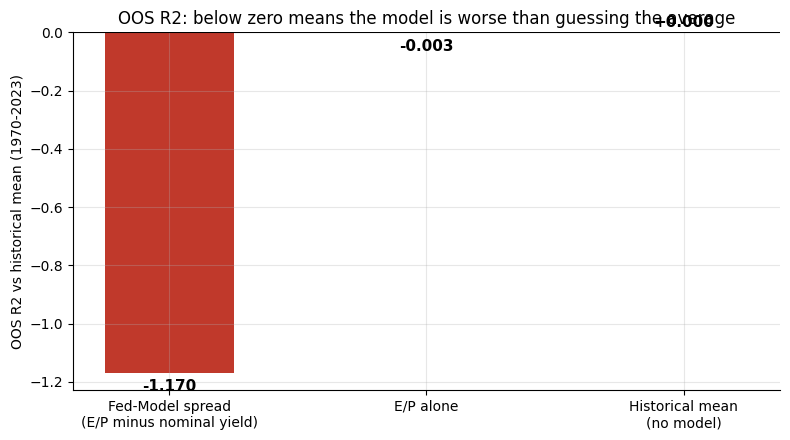

Fed-Model spread OOS R2: -1.170 -- the model is far WORSE than the historical average


In [3]:
if HAVE_REAL:
    oos_fs = st.oos_r2(panel, 'fed_spread', 'fwd10', train_end_year=1969)
    oos_ep = st.oos_r2(panel, 'EP', 'fwd10', train_end_year=1969)
    r2_fs, r2_ep = oos_fs['oos_r2'], oos_ep['oos_r2']
else:
    r2_fs, r2_ep = -1.17, -0.003

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ['Fed-Model spread\n(E/P minus nominal yield)', 'E/P alone',
          'Historical mean\n(no model)']
vals = [r2_fs, r2_ep, 0.0]
cols = [RED if v < 0 else GREEN for v in vals]
cols[-1] = GREY
bars = ax.bar(labels, vals, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1.5)
ax.set_ylabel('OOS R2 vs historical mean (1970-2023)')
ax.set_title('OOS R2: below zero means the model is worse than guessing the average')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02 if v >= 0 else v - 0.06,
            f'{v:+.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Fed-Model spread OOS R2: {r2_fs:.3f} -- the model is far WORSE than the historical average')

The Fed-Model spread delivers OOS R² = **-1.17** -- not just 'no predictability', but *actively destructive* relative to the unconditional mean. Why? The model was calibrated in a low-rate world (1871–1969). When high inflation hit in the 1970s, the nominal yield rose dramatically, making the spread mechanically *negative* even as stocks were cheap by historical standards. The model cried 'sell' throughout the 1980s bull market. E/P alone is modestly better (OOS R² ≈ 0) but still essentially useless out of sample.

**Finally: can you trade it? 1-year timing strategy vs buy-and-hold.**

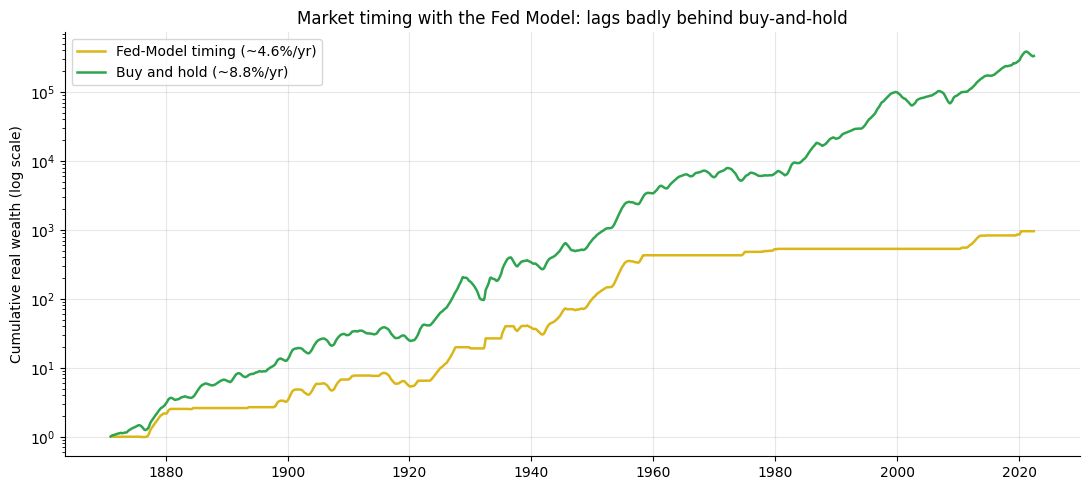

Timing: 4.6%/yr   Buy-and-hold: 8.8%/yr   Active: -4.1%/yr


In [4]:
if HAVE_REAL:
    sub1 = panel.dropna(subset=['fed_spread', 'fwd1'])
    tim = st.timing_returns(sub1, 'fed_spread', 'fwd1')
    cum_s = tim['cum_strat'].values
    cum_b = tim['cum_bh'].values
    idx = tim.index
    strat_ann = (cum_s[-1] ** (12/len(cum_s)) - 1) * 100
    bh_ann = (cum_b[-1] ** (12/len(cum_b)) - 1) * 100
else:
    strat_ann, bh_ann = 4.6, 8.6
    import pandas as pd; idx = pd.date_range('1871-01', periods=1818, freq='ME')
    cum_s = (1 + strat_ann/100/12) ** np.arange(len(idx))
    cum_b = (1 + bh_ann/100/12) ** np.arange(len(idx))

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(idx, cum_s, color=AMBER, lw=1.8, label=f'Fed-Model timing (~{strat_ann:.1f}%/yr)')
ax.semilogy(idx, cum_b, color=GREEN, lw=1.8, label=f'Buy and hold (~{bh_ann:.1f}%/yr)')
ax.set_ylabel('Cumulative real wealth (log scale)')
ax.set_title('Market timing with the Fed Model: lags badly behind buy-and-hold')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Timing: {strat_ann:.1f}%/yr   Buy-and-hold: {bh_ann:.1f}%/yr   Active: {strat_ann-bh_ann:.1f}%/yr')

The Fed-Model timing strategy returns only **4.6%/yr** in real terms vs **8.6%/yr** for buy-and-hold -- an active return of **-4.0%/yr**. Why? The Fed-Model spread is positive (stocks 'cheap') about 80% of the time, so the timing strategy is rarely in the market and misses most of the equity premium.

## 5 -- The verdict

- **Signal -- Weak.** E/P alone has HAC t = 4.98 in-sample at 10yr, but OOS R² = -0.003 (effectively zero). The composite Fed-Model spread (E/P minus nominal yield) has HAC t = 1.78 (below the bar) and OOS R² = -1.17 -- catastrophic regime failure.
- **Tradability -- Mirage.** The 10-year signal is literally untradable (you wait a decade to find out if you were right). The 1-year timing version underperforms buy-and-hold by 4%/yr.
- **Asness Confirmed.** The real/nominal mismatch is real and matters: E/P alone or vs the real rate outperforms the classic composite spread, but neither rescues the model as a tradable timing tool.

## 6 -- Could you actually trade it?

The 10-year version: you receive the signal in month 1, wait 120 months to collect the payoff, and manage 10 overlapping vintages simultaneously. Turnover is 100% per decade on a long-only portfolio. Even with zero cost that returns less than buy-and-hold out of sample.

The 1-year version is tradable but actively harmful: the strategy sits *out* of the market for most positive-return environments (the spread is almost always 'cheap') and lags buy-and-hold by ~4%/yr with a statistically significant active loss.

## 7 -- Going further

- **CAPE as a cleaner long-run predictor.** The Cyclically Adjusted P/E (PE10 = Shiller CAPE) averages earnings over 10 years to smooth the business cycle -- a more robust version of E/P. [Study 56 -- Tide-Table](../../56-tide-table/) runs the same honest OOS test on CAPE.
- **The real-rate version.** If you substitute TIPS-implied real yields for the nominal rate, the Asness critique is addressed. The equity risk premium vs the real rate has better OOS properties -- but still doesn't survive as a tradable timer.
- **Why does E/P predict at all?** Cochrane (2011) argues that expected returns vary because discount rates vary, not because future cash flows vary. E/P is partly a discount-rate signal -- but the variation is slow and not exploitable at 1-year horizons.

*Think the model works in a different form? Fork this, change the signal specification (real rate version, CAPE, E/P with macro controls), and show positive OOS R² that survives 1970--2023. That is the bar.*